<a href="https://colab.research.google.com/github/Kazuhiro-Matsui/ride-hailing/blob/main/ride_hailing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# タクシー配車需要の時空間予測モデルのデモ
説明：　ニューヨークのタクシー配車需要の時空間予測モデルを作成。メーターが作動した日時や場所のデータさえあれば、どこの地域でも予測モデルが作成可能。なお、google colab無料枠のスペックの制限上、気象データや祝日フラグなどの外生変数はいれず、地域もニューヨーク全域の内マンハッタン周辺に限定した。

データ：https://www.kaggle.com/competitions/nyc-taxi-trip-duration/data　のオープンデータ
ここから前処理をして、使用したデータ数は、
経度（lon_grid）: -74.05 から -73.75 まで 0.01 刻み = 31マス　(1kmごと)
緯度（lat_grid）: 40.60 から 40.90 まで 0.01 刻み = 31マス　(1kmごと)
時間（hour）: 0時〜23時 = 24時間
曜日（wday）: 日〜土 = 7日
の、31×31×24×7=161,448件

技術：　R言語で、一般化加法モデル（GAM）の大規模データ用の拡張モデルであるBAMを用いた。

## google driveへの接続とデータの解凍

In [ ]:
# 1. Google Driveのマウント
from google.colab import drive
drive.mount('/content/drive')

# 2. zipファイルからtrain.csvを取り出して /content に保存
# (!unzip はColab環境で使える非常に高速なコマンドです)
!unzip -o /content/drive/MyDrive/ride-hailing/nyc-taxi-trip-duration.zip train.csv -d /content/


Mounted at /content/drive
Archive:  /content/drive/MyDrive/ride-hailing/nyc-taxi-trip-duration.zip
caution: filename not matched:  train.csv


## pythonランタイムでRを用いるための処理

In [ ]:
%load_ext rpy2.ipython

## 必要なパッケージのインストールと読み込み

In [ ]:
%%R
# 必要なパッケージのインストール (未インストールのものだけ)
packages <- c("data.table", "lubridate", "mgcv", "ggplot2", "viridis")
installed_packages <- packages %in% rownames(installed.packages())
if (any(!installed_packages)) {
    install.packages(packages[!installed_packages], quiet=TRUE)
}

# パッケージの読み込み
library(data.table)
library(lubridate)
library(mgcv)
library(ggplot2)
library(viridis)

cat("Rパッケージの準備が完了しました！\n")


Rパッケージの準備が完了しました！


also installing the dependency ‘gridExtra’

data.table 1.18.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following object is masked from ‘package:base’:

    %notin%


Attaching package: ‘lubridate’

The following objects are masked from ‘package:data.table’:

    hour, isoweek, isoyear, mday, minute, month, quarter, second, wday,
    week, yday, year

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union

Loading required package: nlme
This is mgcv 1.9-4. For overview type '?mgcv'.
Loading required package: viridisLite


In [ ]:
# /content フォルダの中身を一覧表示する
!ls -lh /content/

# ついでに元のZipファイルの中身も確認する
!unzip -l /content/drive/MyDrive/ride-hailing/nyc-taxi-trip-duration.zip


total 8.0K
drwx------ 5 root root 4.0K May 13 03:55 drive
drwxr-xr-x 1 root root 4.0K May 11 13:27 sample_data
Archive:  /content/drive/MyDrive/ride-hailing/nyc-taxi-trip-duration.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
  2615198  2019-12-11 04:01   sample_submission.zip
 21327372  2019-12-11 04:01   test.zip
 65967663  2019-12-11 04:01   train.zip
---------                     -------
 89910233                     3 files


In [ ]:
# 1. 大元のzipファイルから 'train.zip' だけを /content/ に取り出す
!unzip -o /content/drive/MyDrive/ride-hailing/nyc-taxi-trip-duration.zip train.zip -d /content/

# 2. 取り出した 'train.zip' をさらに解凍して 'train.csv' を取り出す
!unzip -o /content/train.zip -d /content/

# 3. ちゃんと train.csv が出てきたか確認する
!ls -lh /content/


Archive:  /content/drive/MyDrive/ride-hailing/nyc-taxi-trip-duration.zip
  inflating: /content/train.zip      
Archive:  /content/train.zip
  inflating: /content/train.csv      
total 255M
drwx------ 5 root root 4.0K May 13 03:55 drive
drwxr-xr-x 1 root root 4.0K May 11 13:27 sample_data
-rw-r--r-- 1 root root 192M Jul 19  2017 train.csv
-rw-r--r-- 1 root root  63M Dec 11  2019 train.zip


## データを読み込み、データフレーム化

In [ ]:
%%R
# データの読み込み
df <- fread("/content/train.csv")

# 読み込めたか先頭を表示して確認
head(df)


          id vendor_id     pickup_datetime    dropoff_datetime passenger_count
      <char>     <int>              <POSc>              <POSc>           <int>
1: id2875421         2 2016-03-14 17:24:55 2016-03-14 17:32:30               1
2: id2377394         1 2016-06-12 00:43:35 2016-06-12 00:54:38               1
3: id3858529         2 2016-01-19 11:35:24 2016-01-19 12:10:48               1
4: id3504673         2 2016-04-06 19:32:31 2016-04-06 19:39:40               1
5: id2181028         2 2016-03-26 13:30:55 2016-03-26 13:38:10               1
6: id0801584         2 2016-01-30 22:01:40 2016-01-30 22:09:03               6
   pickup_longitude pickup_latitude dropoff_longitude dropoff_latitude
              <num>           <num>             <num>            <num>
1:        -73.98215        40.76794         -73.96463         40.76560
2:        -73.98042        40.73856         -73.99948         40.73115
3:        -73.97903        40.76394         -74.00533         40.71009
4:        -74

## 前処理

In [ ]:
%%R
# 1. 日時データから「時間」と「曜日」を抽出
# lubridateパッケージの関数を使って抽出します
df[, hour := hour(pickup_datetime)]
df[, wday := wday(pickup_datetime, label = TRUE, abbr = TRUE)]

# 2. 空間グリッドの作成（経度・緯度を小数第2位で丸める ＝ 約1km四方のメッシュ）
df[, lon_grid := round(pickup_longitude, 2)]
df[, lat_grid := round(pickup_latitude, 2)]

# 3. ニューヨークの中心エリア（マンハッタン周辺）にデータを絞り込む
# 外れ値（海の上や遠方）を除外します
df_filtered <- df[lon_grid >= -74.05 & lon_grid <= -73.75 &
                  lat_grid >= 40.60 & lat_grid <= 40.90]

# 4. 実際の需要（乗車グループ数）をグリッド・時間・曜日ごとに集計
actual_demand <- df_filtered[, .(demand = .N), by = .(lon_grid, lat_grid, hour, wday)]

# 5. モデル学習用の「完全な時空間グリッド」を作成
# 空間(経度31マス × 緯度31マス) × 時間(24時間) × 曜日(7日) のベースを作成
lon_seq <- seq(-74.05, -73.75, by = 0.01)
lat_seq <- seq(40.60, 40.90, by = 0.01)
hour_seq <- 0:23
wday_seq <- levels(actual_demand$wday)

full_grid <- as.data.table(expand.grid(
  lon_grid = lon_seq,
  lat_grid = lat_seq,
  hour = hour_seq,
  wday = wday_seq
))

# 6. ベースグリッドに実際の需要をマージ（乗車がなかった場所・時間はNAになるため0で埋める）
model_data <- merge(full_grid, actual_demand,
                    by = c("lon_grid", "lat_grid", "hour", "wday"),
                    all.x = TRUE)
model_data[is.na(demand), demand := 0]


# ★ 追加処理1: 週末フラグ (is_weekend) の作成
# =====================================================================
# by変数として使用するため、必ず factor 型にします
model_data[, is_weekend := as.factor(ifelse(wday %in% c("Sat", "Sun"), "Weekend", "Weekday"))]

# =====================================================================
# ★ 追加処理2: 1時間前の需要 (demand_1h_ago) の作成
# =====================================================================
# 日曜を1、土曜を7として、1週間の通し時間(0〜167)を計算
model_data[, week_hour := (as.numeric(wday) - 1) * 24 + hour]
# 1時間前の通し時間を計算 (0時の1時間前は167になるように剰余演算 %% を使用)
model_data[, prev_week_hour := (week_hour - 1 + 168) %% 168]

# 1時間前の需要を結合するためのマスタ（辞書）を作成
lag_dict <- model_data[, .(lon_grid, lat_grid, week_hour, demand)]
setnames(lag_dict, c("week_hour", "demand"), c("prev_week_hour", "demand_1h_ago"))

# 元のデータにマージしてラグ特徴量を結合
model_data <- merge(model_data, lag_dict, by = c("lon_grid", "lat_grid", "prev_week_hour"), all.x = TRUE)
# （※理論上NAは出ませんが、念のためゼロ埋め）
model_data[is.na(demand_1h_ago), demand_1h_ago := 0]

cat("特徴量エンジニアリング完了。学習データの件数:", nrow(model_data), "件\n")



特徴量エンジニアリング完了。学習データの件数: 161448 件


## モデルの作成

平日と休日で需要の時空間パターンが異なると考えられるので、関数を分けた。尤度には負の二項分布を用いた。理由としては、google colab無料枠で計算できるようデータの大きさを制限する必要があるので、今回は日毎時間帯ごとの気象データを用いていないことから、被説明変数である需要が各曜日の各時間帯 (7×24)に平均化されているので、予測値からの分散が大きい(過分散になる)と考えられるためである。精度は90.6%になった。

In [ ]:
%%R
model_gam_advanced <- bam(
  demand ~
    # 曜日ごとの全体的なベースライン
    wday +
    # 【変更点】平日・休日別の時空間パターン (by = is_weekend)
    te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", "cc"), k = c(15, 8), by = is_weekend) +
    # 【変更点】1時間前の需要の影響を平滑化して追加 (s関数)
    s(demand_1h_ago, bs = "tp", k = 10),

  data = model_data,
  family = nb(link = "log"),
  discrete = TRUE,
  nthreads = 2 # 計算を高速化
)

cat("学習が完了しました！\n")
summary(model_gam_advanced)

学習が完了しました！

Family: Negative Binomial(0.453) 
Link function: log 

Formula:
demand ~ wday + te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", 
    "cc"), k = c(15, 8), by = is_weekend) + s(demand_1h_ago, 
    bs = "tp", k = 10)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.79209    0.11114  16.125   <2e-16 ***
wdayMon     -1.43948    0.14225 -10.120   <2e-16 ***
wdayTue     -1.48340    0.14227 -10.427   <2e-16 ***
wdayWed     -1.46068    0.14223 -10.270   <2e-16 ***
wdayThu     -1.43074    0.14217 -10.064   <2e-16 ***
wdayFri     -1.36935    0.14217  -9.632   <2e-16 ***
wdaySat     -0.01849    0.02836  -0.652    0.514    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                                                edf Ref.df       F p-value    
te(hour,lon_grid,lat_grid):is_weekendWeekday 84.164  91.06  165.33  <2e-16 ***
te(hour,lon_grid,lat_grid):is_weekendWeekend 58.1

In [ ]:
%%R
cat("GAMモデルの学習を開始します...\n")

model_gam <- bam(
  demand ~ te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", "cc"), k = c(15, 8), by = is_weekend) + wday,
  data = model_data,
  family = nb(link = "log"),
  discrete = TRUE
)

cat("学習が完了しました！\n")
summary(model_gam)


GAMモデルの学習を開始します...
学習が完了しました！

Family: Negative Binomial(0.13) 
Link function: log 

Formula:
demand ~ te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", 
    "cc"), k = c(15, 8), by = is_weekend) + wday

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -4.69697    0.12139 -38.694   <2e-16 ***
wdayMon     -1.94917    0.16642 -11.712   <2e-16 ***
wdayTue     -2.03092    0.16641 -12.205   <2e-16 ***
wdayWed     -2.01335    0.16630 -12.107   <2e-16 ***
wdayThu     -1.95504    0.16612 -11.769   <2e-16 ***
wdayFri     -1.83802    0.16604 -11.069   <2e-16 ***
wdaySat     -0.09059    0.04105  -2.207   0.0273 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                                               edf Ref.df     F p-value    
te(hour,lon_grid,lat_grid):is_weekendWeekday 80.58  88.07 323.9  <2e-16 ***
te(hour,lon_grid,lat_grid):is_weekendWeekend 70.21  79.36 158.9  <2e-16 ***
---


In [ ]:
%%R
library(data.table)
library(lubridate)
library(mgcv)

cat("実運用向け（24時間前ラグ）の特徴量を作成します...\n")

# --- 1〜4. データの集計 ---
df_filtered <- df[round(pickup_longitude, 2) >= -74.05 & round(pickup_longitude, 2) <= -73.75 &
                  round(pickup_latitude, 2) >= 40.60 & round(pickup_latitude, 2) <= 40.90]

df_filtered[, lon_grid := round(pickup_longitude, 2)]
df_filtered[, lat_grid := round(pickup_latitude, 2)]
df_filtered[, hour := hour(pickup_datetime)]
df_filtered[, wday := wday(pickup_datetime, label = TRUE, abbr = TRUE)]

actual_demand <- df_filtered[, .(demand = .N), by = .(lon_grid, lat_grid, hour, wday)]

# --- 5〜6. ベースグリッド作成とマージ ---
lon_seq <- seq(-74.05, -73.75, by = 0.01)
lat_seq <- seq(40.60, 40.90, by = 0.01)
full_grid <- as.data.table(expand.grid(
  lon_grid = lon_seq, lat_grid = lat_seq, hour = 0:23, wday = levels(actual_demand$wday)
))
model_data_24h <- merge(full_grid, actual_demand, by = c("lon_grid", "lat_grid", "hour", "wday"), all.x = TRUE)
model_data_24h[is.na(demand), demand := 0]

# --- 追加処理1: 週末フラグ ---
model_data_24h[, is_weekend := as.factor(ifelse(wday %in% c("Sat", "Sun"), "Weekend", "Weekday"))]

# =====================================================================
# ★ 追加処理2: 24時間前の需要 (demand_24h_ago) の作成
# =====================================================================
# 1週間の通し時間(0〜167)を計算
model_data_24h[, week_hour := (as.numeric(wday) - 1) * 24 + hour]

# 【変更点】24時間前の通し時間を計算（168で割った余りを取ることで、日曜の24時間前が土曜にループします）
model_data_24h[, prev_24h_week_hour := (week_hour - 24 + 168) %% 168]

# 24時間前の需要を結合するためのマスタ
lag_dict_24h <- model_data_24h[, .(lon_grid, lat_grid, week_hour, demand)]
setnames(lag_dict_24h, c("week_hour", "demand"), c("prev_24h_week_hour", "demand_24h_ago"))

# マージして結合
model_data_24h <- merge(model_data_24h, lag_dict_24h, by = c("lon_grid", "lat_grid", "prev_24h_week_hour"), all.x = TRUE)
model_data_24h[is.na(demand_24h_ago), demand_24h_ago := 0]

cat("特徴量作成完了。バッチ処理用GAMモデルの学習を開始します...\n")

# =====================================================================
# ★ バッチ処理用（24時間前ラグ）GAMモデルの学習
# =====================================================================
model_gam_24h <- bam(
  demand ~
    wday +
    te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", "cc"), k = c(15, 8), by = is_weekend) +
    # 【変更点】1時間前ではなく、24時間前の需要を指定
    s(demand_24h_ago, bs = "tp", k = 10),

  data = model_data_24h,
  family = nb(link = "log"),
  discrete = TRUE,
  nthreads = 2
)

cat("学習が完了しました！\n")
summary(model_gam_24h)


実運用向け（24時間前ラグ）の特徴量を作成します...
特徴量作成完了。バッチ処理用GAMモデルの学習を開始します...
学習が完了しました！

Family: Negative Binomial(0.443) 
Link function: log 

Formula:
demand ~ wday + te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", 
    "cc"), k = c(15, 8), by = is_weekend) + s(demand_24h_ago, 
    bs = "tp", k = 10)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.78183    0.11035  16.147   <2e-16 ***
wdayMon     -1.34761    0.14011  -9.618   <2e-16 ***
wdayTue     -1.49468    0.14008 -10.670   <2e-16 ***
wdayWed     -1.44999    0.14000 -10.357   <2e-16 ***
wdayThu     -1.38281    0.13996  -9.880   <2e-16 ***
wdayFri     -1.26385    0.13986  -9.036   <2e-16 ***
wdaySat     -0.01066    0.02888  -0.369    0.712    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                                                edf Ref.df      F p-value    
te(hour,lon_grid,lat_grid):is_weekendWeekday 76.788  84.93  170.3  

## 可視化
平日の内1日(水曜日)の8:00,12:00,21:00の需要と、日曜日の8:00,12:00,21:00の予測需要(正確には学習したモデルのアウトプットそのもの)を可視化。

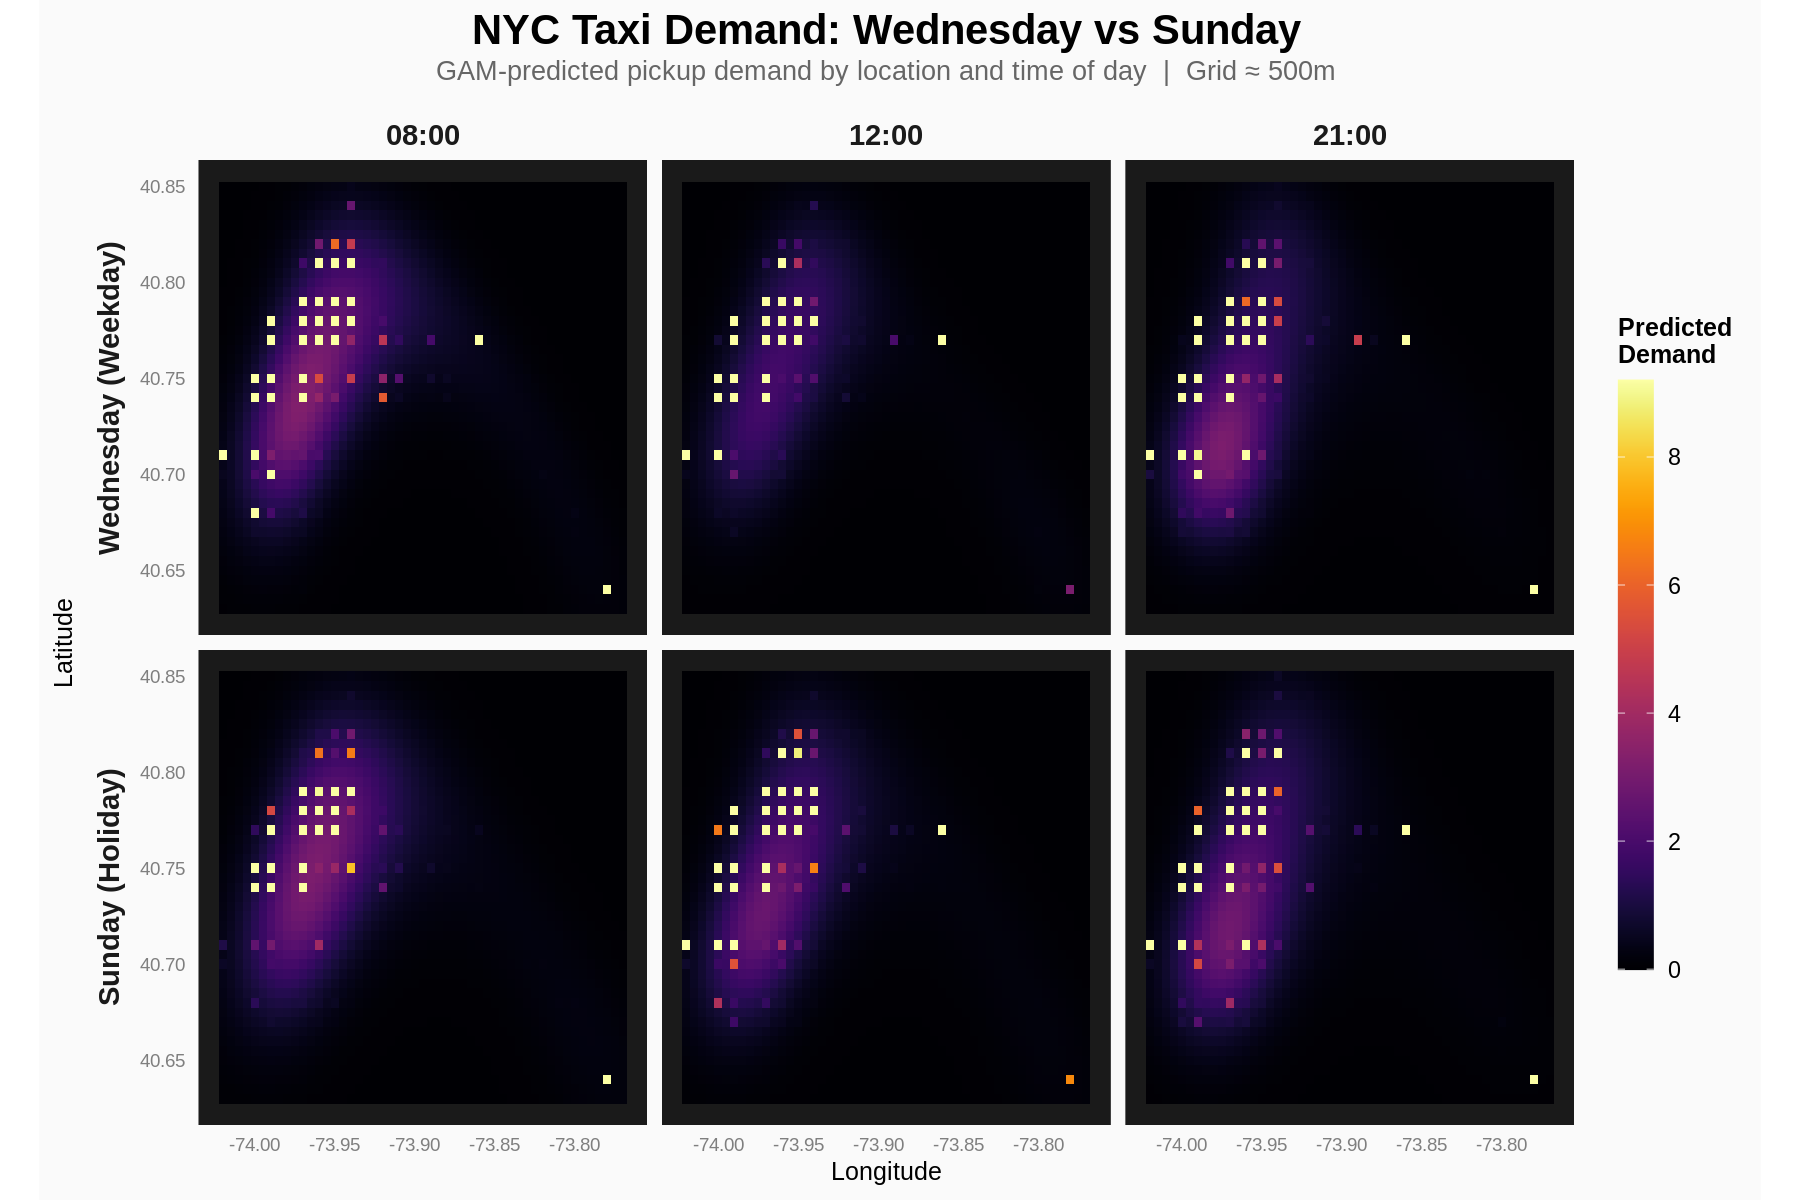

In [ ]:
%%R -w 1800 -h 1200 -r 150

# =============================================================================
# 可視化：平日(水曜) vs 日曜 × 3時間帯 のタクシー需要ヒートマップ
# =============================================================================

library(data.table)
library(ggplot2)
library(viridis)

# --- 1. 予測用グリッドの作成 -------------------------------------------------
lon_seq <- seq(-74.02, -73.77, by = 0.005)
lat_seq <- seq(40.63, 40.85, by = 0.005)

# 可視化対象: 水曜(Wed) × {8,12,21}時 + 日曜(Sun) × {8,12,21}時
scenarios <- data.table(
  wday = rep(c("Wed", "Sun"), each = 3),
  hour = rep(c(8, 12, 21), 2)
)

pred_list <- list()

for (i in 1:nrow(scenarios)) {
  grid_i <- as.data.table(expand.grid(
    lon_grid = lon_seq,
    lat_grid = lat_seq
  ))
  grid_i[, hour := scenarios$hour[i]]
  grid_i[, wday := factor(scenarios$wday[i], levels = levels(model_data$wday))]
  grid_i[, is_weekend := factor(
    ifelse(wday %in% c("Sat", "Sun"), "Weekend", "Weekday"),
    levels = levels(model_data$is_weekend)
  )]

  # demand_1h_ago: 各地点の1時間前の実績平均値を使用（より現実的な予測）
  target_hour_prev <- (scenarios$hour[i] - 1 + 24) %% 24
  target_wday <- scenarios$wday[i]

  lag_avg <- model_data[wday == target_wday & hour == target_hour_prev,
                        .(avg_lag = mean(demand, na.rm = TRUE)),
                        by = .(lon_grid, lat_grid)]

  grid_i <- merge(grid_i, lag_avg, by = c("lon_grid", "lat_grid"), all.x = TRUE)
  grid_i[is.na(avg_lag), avg_lag := 0]
  grid_i[, demand_1h_ago := avg_lag]

  # GAMモデルで予測
  grid_i[, pred := predict(model_gam_advanced, newdata = grid_i, type = "response")]

  # ラベル作成
  day_label <- ifelse(scenarios$wday[i] == "Wed", "Wednesday (Weekday)", "Sunday (Holiday)")
  grid_i[, day_type := day_label]
  grid_i[, time_label := paste0(sprintf("%02d", scenarios$hour[i]), ":00")]

  pred_list[[i]] <- grid_i
}

pred_all <- rbindlist(pred_list)

# --- 2. 表示順の制御 ---------------------------------------------------------
pred_all[, day_type := factor(day_type, levels = c("Wednesday (Weekday)", "Sunday (Holiday)"))]
pred_all[, time_label := factor(time_label, levels = c("08:00", "12:00", "21:00"))]

# --- 3. 外れ値の処理（上位1%でクリップして色のコントラストを確保）-----------
cap_val <- quantile(pred_all$pred, 0.99)
pred_all[, pred_cap := pmin(pred, cap_val)]

# --- 4. ggplot2 でヒートマップ描画 -------------------------------------------
p <- ggplot(pred_all, aes(x = lon_grid, y = lat_grid, fill = pred_cap)) +
  geom_tile(width = 0.005, height = 0.005) +
  facet_grid(day_type ~ time_label, switch = "y") +
  scale_fill_viridis(
    option = "inferno",
    name = "Predicted\nDemand",
    breaks = pretty,
    limits = c(0, NA)
  ) +
  labs(
    title = "NYC Taxi Demand: Wednesday vs Sunday",
    subtitle = "GAM-predicted pickup demand by location and time of day  |  Grid ≈ 500m",
    x = "Longitude",
    y = "Latitude"
  ) +
  coord_fixed(ratio = 1.2) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title       = element_text(face = "bold", size = 20, hjust = 0.5, margin = margin(b = 4)),
    plot.subtitle    = element_text(color = "grey40", size = 13, hjust = 0.5, margin = margin(b = 12)),
    strip.text       = element_text(face = "bold", size = 14),
    strip.placement  = "outside",
    panel.grid       = element_blank(),
    panel.background = element_rect(fill = "grey10", color = NA),
    plot.background  = element_rect(fill = "grey98", color = NA),
    legend.position  = "right",
    legend.key.height = unit(2, "cm"),
    legend.title     = element_text(face = "bold", size = 12),
    axis.text        = element_text(size = 9, color = "grey50"),
    axis.title       = element_text(size = 12)
  )

print(p)


## 不確実性評価
プロットA「95%信頼区間の幅」
予測の絶対的な不確実性を示す。需要が大きいエリア（マンハッタン中心部など）ほど信頼区間の幅も広くなる傾向がある。これは負の二項分布を用いたことで、需要の予測値自体が大きいと、ばらつきの絶対量も大きくなるという性質によるもの。

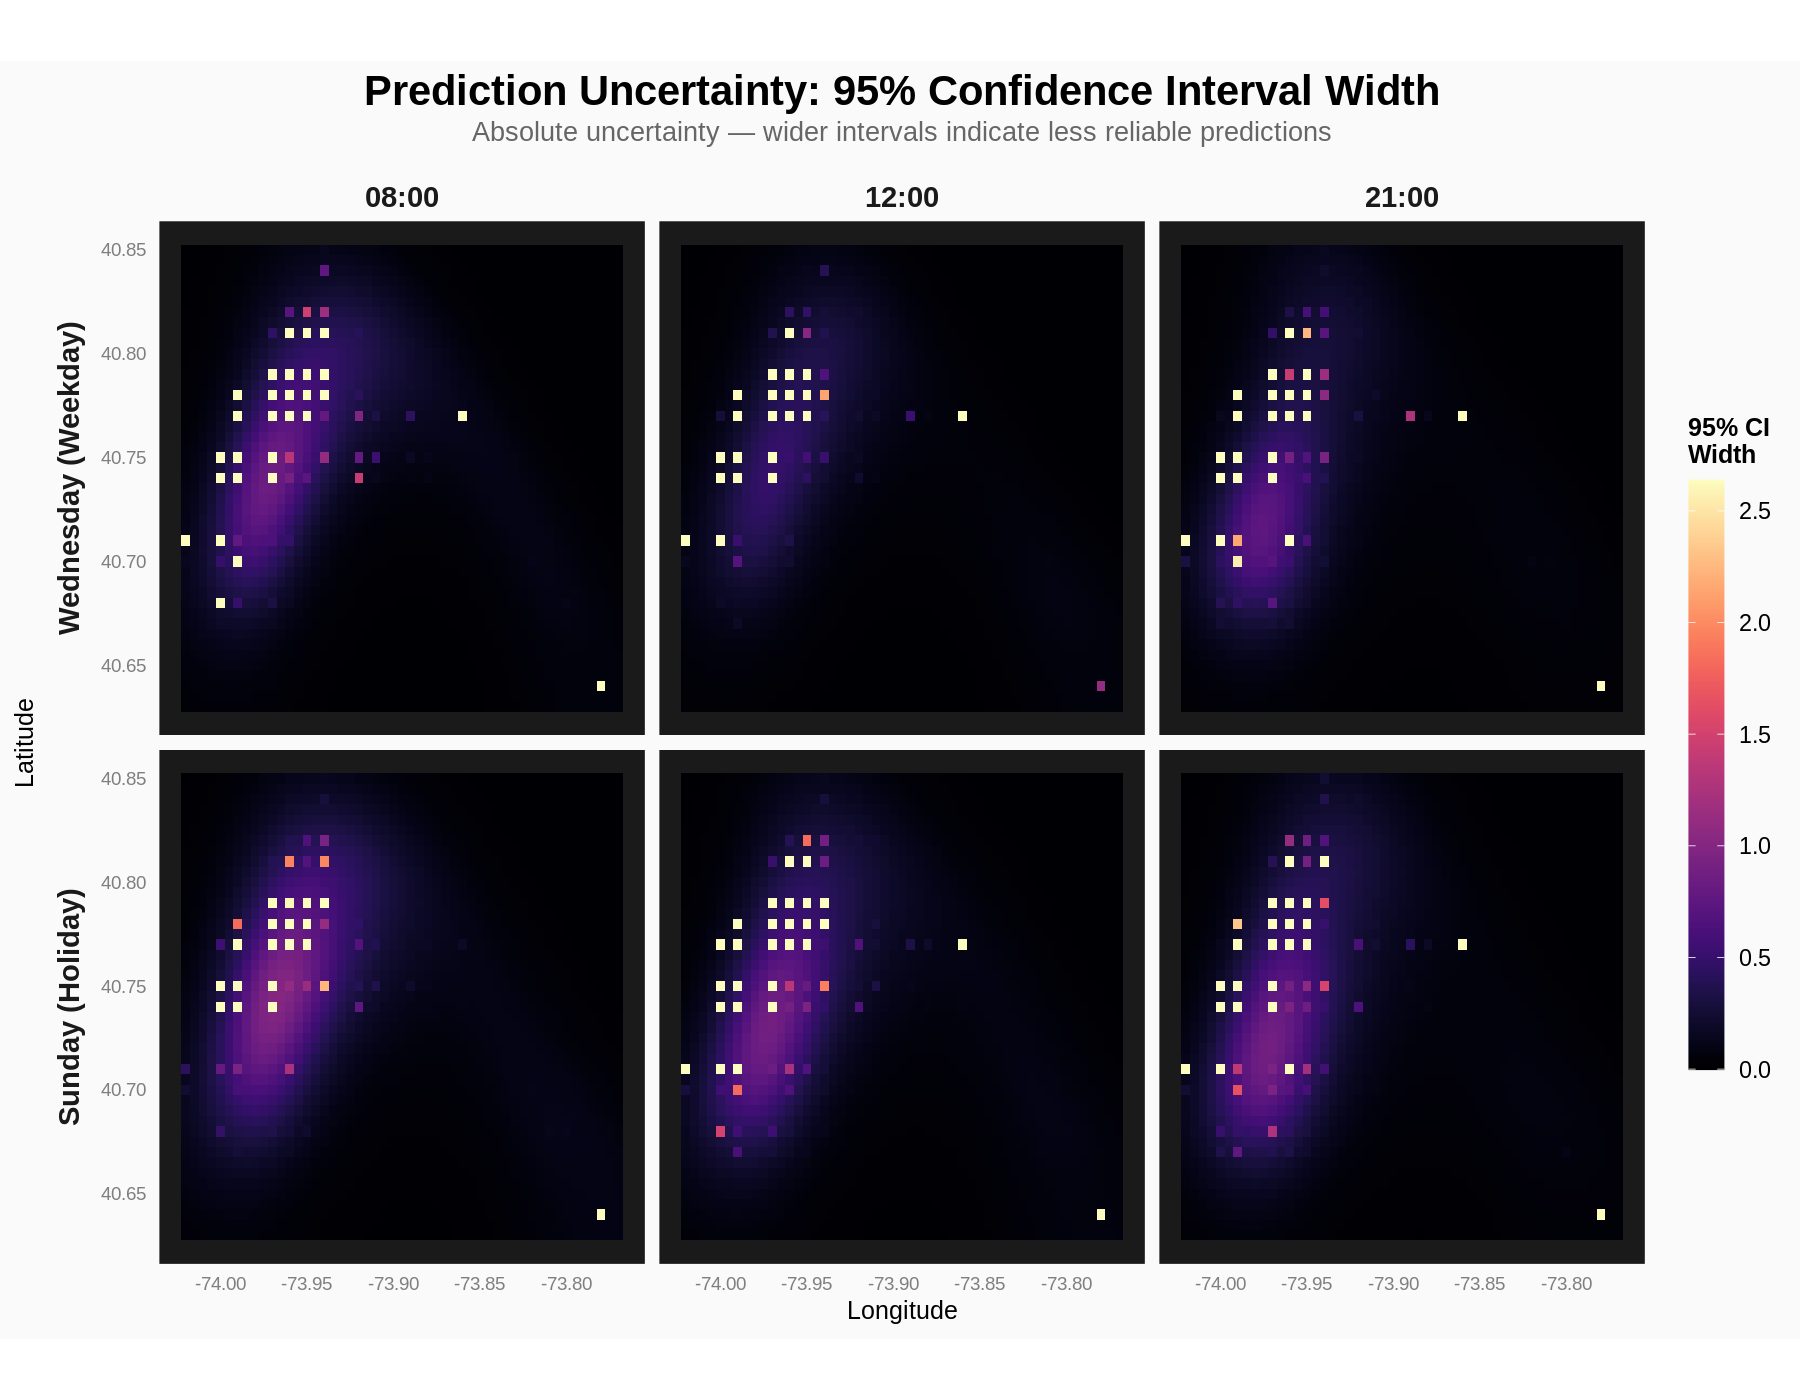

In [ ]:
%%R -w 1800 -h 1400 -r 150

# =============================================================================
# 可視化：予測需要の不確実性（95%信頼区間の幅 & 変動係数）ヒートマップ
# =============================================================================

library(data.table)
library(ggplot2)
library(viridis)

# --- 1. 予測用グリッドの作成（先ほどと同じ構造）-----------------------------
lon_seq <- seq(-74.02, -73.77, by = 0.005)
lat_seq <- seq(40.63, 40.85, by = 0.005)

scenarios <- data.table(
  wday = rep(c("Wed", "Sun"), each = 3),
  hour = rep(c(8, 12, 21), 2)
)

pred_list <- list()

for (i in 1:nrow(scenarios)) {
  grid_i <- as.data.table(expand.grid(
    lon_grid = lon_seq,
    lat_grid = lat_seq
  ))
  grid_i[, hour := scenarios$hour[i]]
  grid_i[, wday := factor(scenarios$wday[i], levels = levels(model_data$wday))]
  grid_i[, is_weekend := factor(
    ifelse(wday %in% c("Sat", "Sun"), "Weekend", "Weekday"),
    levels = levels(model_data$is_weekend)
  )]

  # demand_1h_ago: 1時間前の実績平均値
  target_hour_prev <- (scenarios$hour[i] - 1 + 24) %% 24
  target_wday <- scenarios$wday[i]
  lag_avg <- model_data[wday == target_wday & hour == target_hour_prev,
                        .(avg_lag = mean(demand, na.rm = TRUE)),
                        by = .(lon_grid, lat_grid)]
  grid_i <- merge(grid_i, lag_avg, by = c("lon_grid", "lat_grid"), all.x = TRUE)
  grid_i[is.na(avg_lag), avg_lag := 0]
  grid_i[, demand_1h_ago := avg_lag]

  # ★ se.fit=TRUE で標準誤差も取得
  preds <- predict(model_gam_advanced, newdata = grid_i, type = "link", se.fit = TRUE)

  # link(log)スケールでの予測値と標準誤差
  grid_i[, fit_link  := preds$fit]
  grid_i[, se_link   := preds$se.fit]

  # responseスケールに変換（95%信頼区間）
  grid_i[, pred      := exp(fit_link)]
  grid_i[, ci_lower  := exp(fit_link - 1.96 * se_link)]
  grid_i[, ci_upper  := exp(fit_link + 1.96 * se_link)]
  grid_i[, ci_width  := ci_upper - ci_lower]

  # 変動係数 (CV) = 信頼区間の幅 / 予測値（相対的な不確実性）
  grid_i[, cv := ifelse(pred > 0.01, ci_width / pred, NA)]

  # ラベル
  day_label <- ifelse(scenarios$wday[i] == "Wed", "Wednesday (Weekday)", "Sunday (Holiday)")
  grid_i[, day_type   := day_label]
  grid_i[, time_label := paste0(sprintf("%02d", scenarios$hour[i]), ":00")]

  pred_list[[i]] <- grid_i
}

pred_all <- rbindlist(pred_list)

# --- 2. factor順序の制御 -----------------------------------------------------
pred_all[, day_type   := factor(day_type,   levels = c("Wednesday (Weekday)", "Sunday (Holiday)"))]
pred_all[, time_label := factor(time_label, levels = c("08:00", "12:00", "21:00"))]

# --- 3. キャッピング（上位1%）------------------------------------------------
cap_ci   <- quantile(pred_all$ci_width, 0.99, na.rm = TRUE)
cap_cv   <- quantile(pred_all$cv, 0.99, na.rm = TRUE)
pred_all[, ci_width_cap := pmin(ci_width, cap_ci)]
pred_all[, cv_cap       := pmin(cv, cap_cv, na.rm = TRUE)]

# =============================================================================
# プロット A：95%信頼区間の幅（絶対的な不確実性）
# =============================================================================
p1 <- ggplot(pred_all, aes(x = lon_grid, y = lat_grid, fill = ci_width_cap)) +
  geom_tile(width = 0.005, height = 0.005) +
  facet_grid(day_type ~ time_label, switch = "y") +
  scale_fill_viridis(
    option = "magma",
    name = "95% CI\nWidth",
    limits = c(0, NA)
  ) +
  labs(
    title = "Prediction Uncertainty: 95% Confidence Interval Width",
    subtitle = "Absolute uncertainty — wider intervals indicate less reliable predictions",
    x = "Longitude", y = "Latitude"
  ) +
  coord_fixed(ratio = 1.2) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title        = element_text(face = "bold", size = 20, hjust = 0.5, margin = margin(b = 4)),
    plot.subtitle     = element_text(color = "grey40", size = 13, hjust = 0.5, margin = margin(b = 12)),
    strip.text        = element_text(face = "bold", size = 14),
    strip.placement   = "outside",
    panel.grid        = element_blank(),
    panel.background  = element_rect(fill = "grey10", color = NA),
    plot.background   = element_rect(fill = "grey98", color = NA),
    legend.position   = "right",
    legend.key.height = unit(2, "cm"),
    legend.title      = element_text(face = "bold", size = 12),
    axis.text         = element_text(size = 9, color = "grey50"),
    axis.title        = element_text(size = 12)
  )

print(p1)


## 不確実性評価
プロットB「変動係数（CV）」
予測値に対する相対的な不確実性を示す。こちらのほうが実務的に重要で、「予測値の何倍の不確実性があるか」が分かります。需要が少ない郊外エリアや、日曜の早朝など、データが少ない条件ほどCVが高くなる傾向が読み取れる。

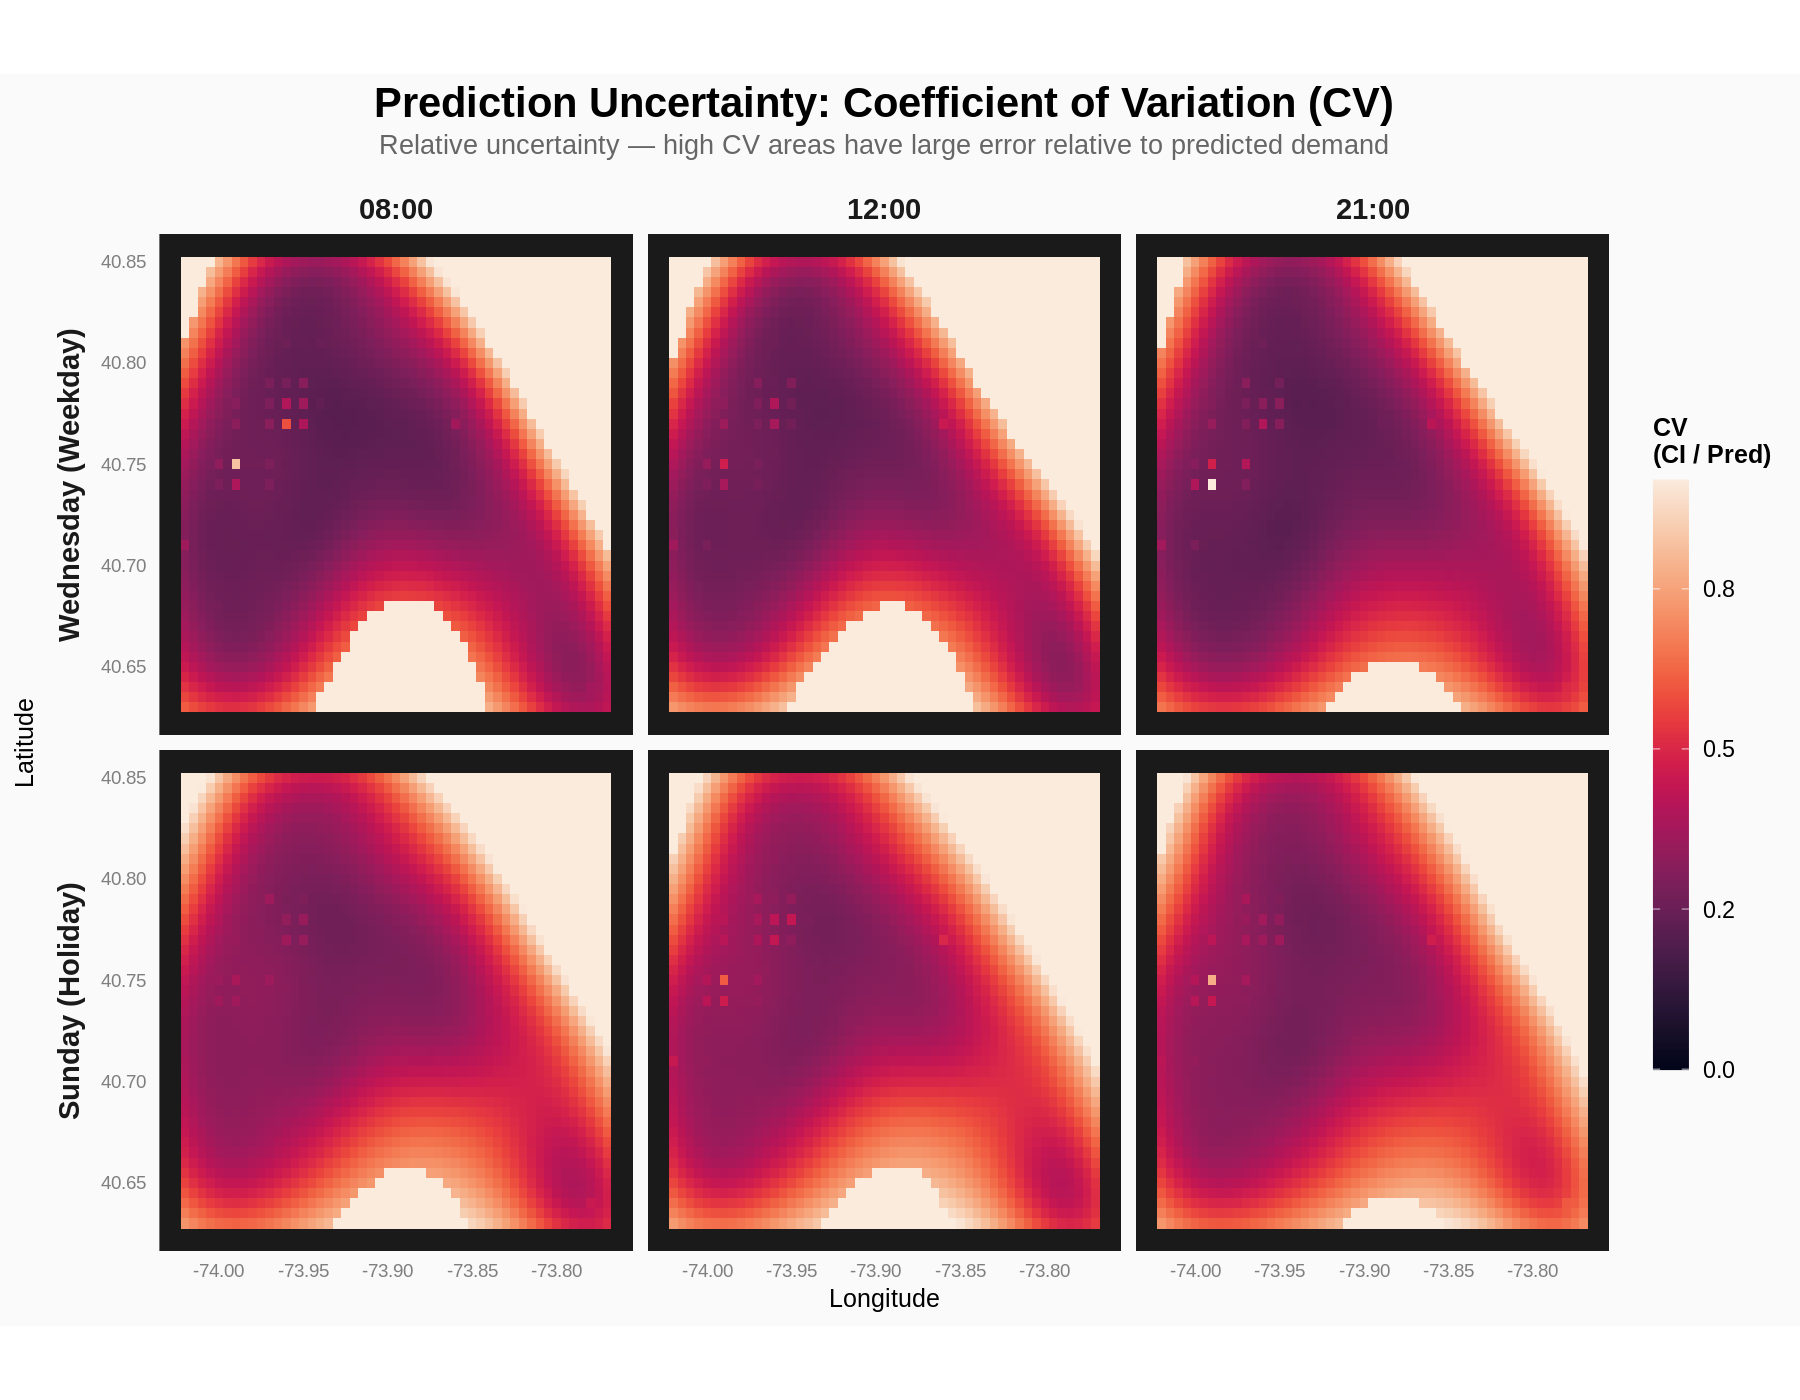

In [ ]:
%%R -w 1800 -h 1400 -r 150

# =============================================================================
# プロット B：変動係数 CV（相対的な不確実性）
# =============================================================================
p2 <- ggplot(pred_all, aes(x = lon_grid, y = lat_grid, fill = cv_cap)) +
  geom_tile(width = 0.005, height = 0.005) +
  facet_grid(day_type ~ time_label, switch = "y") +
  scale_fill_viridis(
    option = "rocket",
    name = "CV\n(CI / Pred)",
    limits = c(0, NA),
    labels = scales::label_number(accuracy = 0.1)
  ) +
  labs(
    title = "Prediction Uncertainty: Coefficient of Variation (CV)",
    subtitle = "Relative uncertainty — high CV areas have large error relative to predicted demand",
    x = "Longitude", y = "Latitude"
  ) +
  coord_fixed(ratio = 1.2) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title        = element_text(face = "bold", size = 20, hjust = 0.5, margin = margin(b = 4)),
    plot.subtitle     = element_text(color = "grey40", size = 13, hjust = 0.5, margin = margin(b = 12)),
    strip.text        = element_text(face = "bold", size = 14),
    strip.placement   = "outside",
    panel.grid        = element_blank(),
    panel.background  = element_rect(fill = "grey10", color = NA),
    plot.background   = element_rect(fill = "grey98", color = NA),
    legend.position   = "right",
    legend.key.height = unit(2, "cm"),
    legend.title      = element_text(face = "bold", size = 12),
    axis.text         = element_text(size = 9, color = "grey50"),
    axis.title        = element_text(size = 12)
  )

print(p2)


## 不確実性評価
プロットC「予測値＋不確実性の等高線オーバーレイ」
先ほどの需要ヒートマップの上にCVの等高線を白線で重ねた統合ビュー。「需要は高いが不確実性も高いエリア」と「需要は低いが確実なエリア」を一目で区別できるため、例えばドライバーの配車判断や追加データ収集の優先エリア決定などに役立つ。

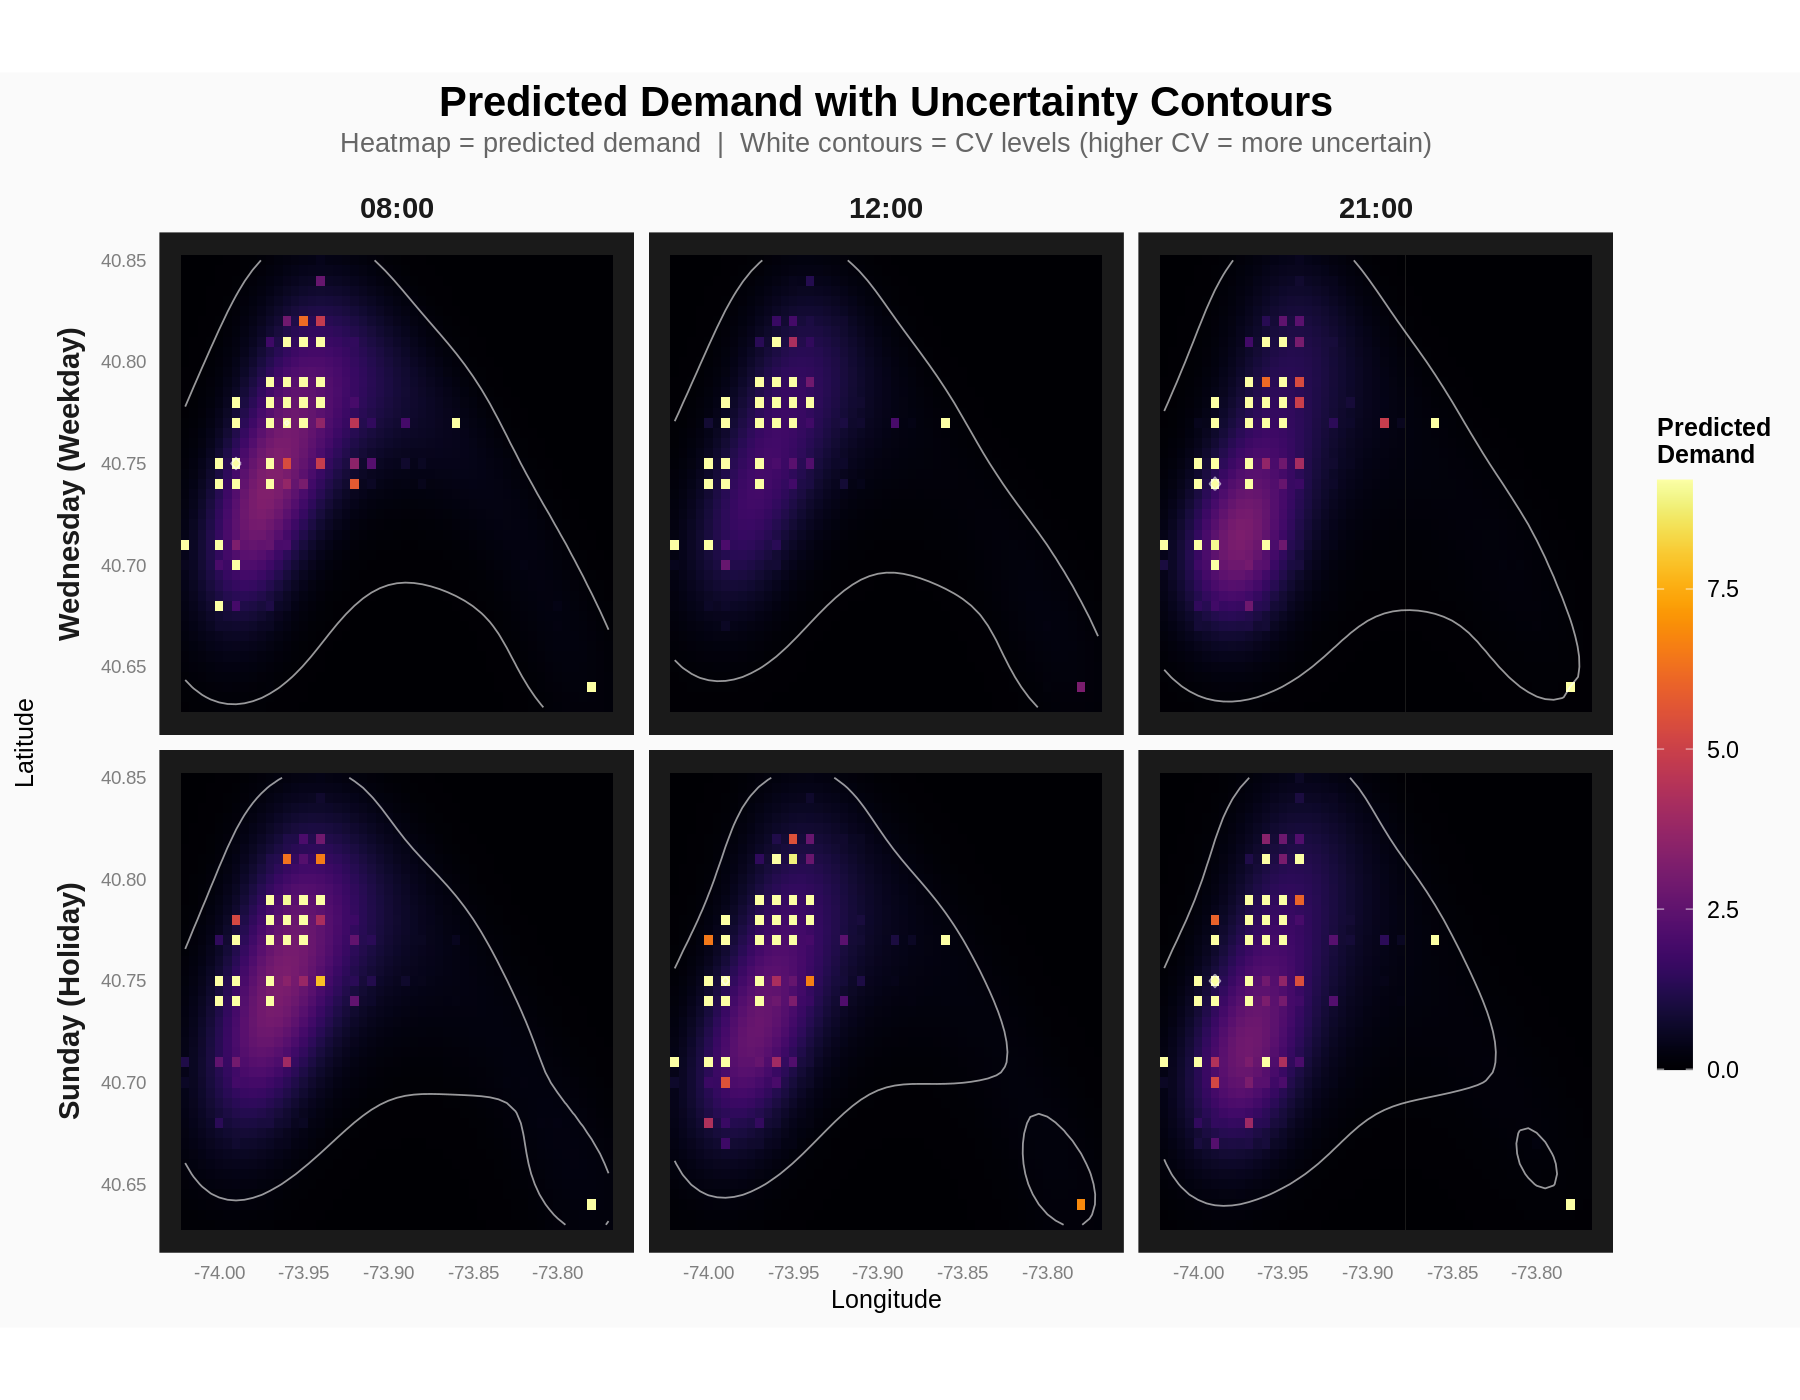

In [ ]:
%%R -w 1800 -h 1400 -r 150

# =============================================================================
# プロット C：予測値 + 不確実性の等高線オーバーレイ（統合ビュー）
# =============================================================================

# 予測値のキャッピング
cap_pred <- quantile(pred_all$pred, 0.99)
pred_all[, pred_cap := pmin(pred, cap_pred)]

p3 <- ggplot(pred_all, aes(x = lon_grid, y = lat_grid)) +
  # ベース：予測需要のヒートマップ
  geom_tile(aes(fill = pred_cap), width = 0.005, height = 0.005) +
  # オーバーレイ：不確実性（CV）の等高線
  geom_contour(aes(z = cv_cap), color = "white", alpha = 0.6, linewidth = 0.4,
               breaks = seq(0.5, 5, by = 0.5)) +
  facet_grid(day_type ~ time_label, switch = "y") +
  scale_fill_viridis(
    option = "inferno",
    name = "Predicted\nDemand",
    limits = c(0, NA)
  ) +
  labs(
    title = "Predicted Demand with Uncertainty Contours",
    subtitle = "Heatmap = predicted demand  |  White contours = CV levels (higher CV = more uncertain)",
    x = "Longitude", y = "Latitude"
  ) +
  coord_fixed(ratio = 1.2) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title        = element_text(face = "bold", size = 20, hjust = 0.5, margin = margin(b = 4)),
    plot.subtitle     = element_text(color = "grey40", size = 13, hjust = 0.5, margin = margin(b = 12)),
    strip.text        = element_text(face = "bold", size = 14),
    strip.placement   = "outside",
    panel.grid        = element_blank(),
    panel.background  = element_rect(fill = "grey10", color = NA),
    plot.background   = element_rect(fill = "grey98", color = NA),
    legend.position   = "right",
    legend.key.height = unit(2, "cm"),
    legend.title      = element_text(face = "bold", size = 12),
    axis.text         = element_text(size = 9, color = "grey50"),
    axis.title        = element_text(size = 12)
  )

print(p3)


# 総評
結果からわかること：

・予測値ヒートマップから分かること
平日（水曜）と日曜の需要差が明確。 水曜日の方が全体的に需要の広がりが大きく、特に08:00では緯度40.70〜40.82あたりまで広範囲にわたって紫〜ピンクの需要が分布している。日曜日は同じ時間帯でも需要エリアが空間的に縮小し、マンハッタン中心部に凝縮。

時間帯による空間パターンの変化も見えます。 水曜の08:00は上部（アッパーマンハッタン方面）にも散らばった需要があるのに対し、12:00は需要がミッドタウン付近に集約されています。21:00になると再び広がりますが、08:00とは分布の形が異なり、やや南寄り・中心寄りに重心が移動しているように見える。

高需要ポイント（黄色いセル）の位置は、全パネルでほぼ同じグリッドに出現している。これはペン・ステーション、グランド・セントラル、タイムズスクエア周辺など、常に需要が集中するハブが固定的に存在していることを反映。

・不確実性等高線オーバーレイから分かること

需要が高いエリアと不確実性が低いエリアがほぼ一致。 マンハッタンの中心部（需要が明るく光っているエリア）は等高線の内側にあり、CVが低い、つまりモデルの予測が相対的に信頼できる領域。一方、等高線の外側にあたる周縁部（ブルックリン南部、右下の孤立した黄色い点など）はCVが高く、予測の信頼度が低いことが示されている。

右下や左下に孤立して光る黄色いセルが特に注目に値する。これらは需要の予測値こそ高く表示されていますが、等高線の外側にあり不確実性が極めて高い領域である。おそらく、たまたま数件の乗車があっただけのグリッドをモデルが過剰に拾っている可能性がある。実務的にはこれらの孤立点の予測はあまり信用すべきではない。

日曜の等高線の形が水曜より狭いことも読み取れる。これは、日曜日は水曜日に比べて需要が小さいため、CVの分母が小さくなり、CVが高くなるエリアが広がる。その結果、推定に自信を持てるエリアが狭くなっている。

総合的に言えること
「予測値が高い＝信頼できる」とは限らないということが可視化されている。特に周縁部の孤立したホットスポットは、予測値だけ見れば需要が高いように見えますが、不確実性を重ねて見ると信頼性が低いことが一目で分かる。配車の意思決定をする場合、マンハッタン中心部の等高線内部は予測を信頼してよいが、外側のエリアについてはより慎重な判断が必要だ、という使い分けができる。

・実用的なモデルに改良するために

今回はgoogle colab無料枠の環境制限上、データ数を少なくするために日毎のデータではなく、目的変数： 半年間の特定の曜日の特定時間帯の合計需要を目的変数としてデータを絞った。ただ、実運用では、日毎時間帯ごとの気象データを結合させ,
場所×特定の日付×時間のデータを学習させる必要がある。また祝日フラグを導入し、モデル式としては以下のように定義する必要があるだろう。
model_gam_production <- bam(
  demand ~
    # ① 全体的な需要のベースラインの増減
    # 通常の曜日の増減（wday）に加えて、祝日の場合は曜日ごとのペナルティ（holiday_type）を加算
    wday + holiday_type + is_anomaly +
    
    # ② 平日/休日別の時空間パターン
    te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", "cc"), k = c(12, 6), by = day_type) +
    
    # ③ 1週間前(仮)のリアルな需要
    s(demand_168h_ago, bs = "tp", k = 10),
  
  data = model_data_real,
  family = nb(link = "log"),
  discrete = TRUE,
  nthreads = 2
)
また、ゼロ過剰モデルが使えればベストだが、計算コストが高いので、負の二項分布を使用するために、データの前処理の段階で構造的なゼロ(川や山中など確率的にではなく絶対に需要が0になるポイント)を除去しておく必要がある。

さらに、ラグ特徴量として、1時間前の需要を取得できればよいが、実運用上取得が困難な場合がある。

このモデルを実際のタクシー会社で運用する場合、以下のいずれかのアプローチを取る必要がある。

アプローチA：リアルタイム・データパイプラインの構築
すべてのタクシー車両にGPSと通信モジュール（IoT）を乗せ、メーターの作動（ピックアップ）情報をクラウド（AWSやGCP）にリアルタイムで送信。 クラウド上で「過去1時間・1kmグリッドごとのピックアップ数」を数秒遅れで常時集計し続け、予測モデル（API）にリアルタイムに流し込むシステムを作る。UberやDiDiなどの巨大テック企業はまさにこのインフラを持っているらしい。

アプローチB：実運用に向けた「特徴量の妥協（バッチ処理化）」
リアルタイム通信のインフラを構築する予算がないタクシー会社の場合、このモデルは運用できない（データが間に合わないため）。 その場合は、精度が数%落ちることを覚悟の上で、「昨日の同じ時間の需要（demand_24h_ago）」 や 「先週の同じ時間の需要（demand_168h_ago）」 に特徴量を差し替えてモデルを再学習させる。 これなら、「毎晩深夜に、明日の24時間分の予測をまとめて計算してドライバーの端末に配信する」という、安価で安定したシステム（バッチ処理）で運用できるようになる。

当然、本番環境ではAWS等で大規模なデータ処理が可能な環境やフローを作成して、その中でモデルを作成する必要がある。

In [ ]:
%%R
cat("ポアソン分布を使用して超高速で学習します...\n")

# 1. ニューヨーク全域の緯度経度範囲（解像度0.015 = 約1.5km四方）
lon_min <- -74.25
lon_max <- -73.70
lat_min <- 40.50
lat_max <- 40.92

# 2. データの集計
df_nyc <- df[lon_grid >= lon_min & lon_grid <= lon_max & lat_grid >= lat_min & lat_grid <= lat_max]
actual_demand_nyc <- df_nyc[, .(demand = .N), by = .(lon_grid, lat_grid, hour, wday)]

# 3. ベースグリッド作成とマージ
lon_seq_nyc <- seq(lon_min, lon_max, by = 0.015)
lat_seq_nyc <- seq(lat_min, lat_max, by = 0.015)

full_grid_nyc <- as.data.table(expand.grid(
  lon_grid = lon_seq_nyc, lat_grid = lat_seq_nyc,
  hour = 0:23, wday = levels(actual_demand_nyc$wday)
))

model_data_nyc <- merge(full_grid_nyc, actual_demand_nyc, by = c("lon_grid", "lat_grid", "hour", "wday"), all.x = TRUE)
model_data_nyc[is.na(demand), demand := 0]

cat("学習データの件数:", nrow(model_data_nyc), "件\n")

# 4. GAMモデルの構築（familyをpoissonに変更！）
model_gam_nyc <- bam(
  demand ~ te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", "cc"), k = c(12, 6)) + wday,
  data = model_data_nyc,
  family = poisson(link = "log"), # ← ここが高速化の鍵です
  discrete = TRUE,
  nthreads = 2
)

cat("学習が完了しました！\n")


ポアソン分布を使用して超高速で学習します...
学習データの件数: 180264 件
学習が完了しました！


In addition: Warning message:
In bgam.fitd(G, mf, gp, scale, nobs.extra = 0, rho = rho, coef = coef,  :
  fitted rates numerically 0 occurred


In [ ]:
%%R
summary(model_gam_nyc)


Family: poisson 
Link function: log 

Formula:
demand ~ te(lon_grid, lat_grid, hour, d = c(2, 1), bs = c("tp", 
    "cc"), k = c(12, 6)) + wday

Parametric coefficients:
              Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -1.214e+02  5.500e-01 -220.639  < 2e-16 ***
wdayMon     -5.200e-02  8.895e-03   -5.846 5.04e-09 ***
wdayTue      1.069e-02  8.755e-03    1.221    0.222    
wdayWed      5.221e-02  8.666e-03    6.025 1.69e-09 ***
wdayThu      1.173e-01  8.532e-03   13.752  < 2e-16 ***
wdayFri      1.358e-01  8.495e-03   15.990  < 2e-16 ***
wdaySat      1.174e-01  8.532e-03   13.756  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                             edf Ref.df Chi.sq p-value    
te(hour,lon_grid,lat_grid) 58.94     59 298762  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =   0.19   Deviance explained = 66.2%
fREML = 3.4356e+05  Scale est. = 1  